#### Extreem Gradient Boost

  `Decision Trees: The Building Blocks`

Imagine you’re a customer retention manager trying to decide whether a customer will churn (leave) or stay.

You look at each customer’s data:

Monthly spending 

Number of transactions 

Contract duration 

Support calls made 

You start asking yes/no questions to make decisions — kind of like 20 Questions.

Example:

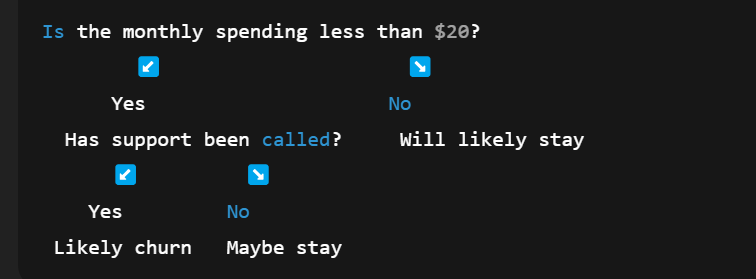


 That’s a decision tree  — a series of rules that split customers into groups, ending with a prediction at the leaves (“churn” or “stay”).

Each split tries to separate the data so that each branch is as pure as possible (mostly churners on one side, mostly non-churners on the other).


  `What’s Wrong With One Tree?`

A single tree is simple and interpretable — but it can be:

Too specific (memorizes instead of generalizing)

Unstable (small data changes → big prediction changes)

So instead of using one big tree, XGBoost builds many small trees that work together.

 `Enter XGBoost: “Extreme Gradient Boosting”`

XGBoost (short for eXtreme Gradient Boosting) is like a team of trees  working in sequence, where:

Each new tree tries to fix the mistakes made by the previous ones.

The model learns step by step, getting better each round.

Here’s the idea simplified 


`Tree 1: makes first rough guesses.`

`Tree 2: focuses on where Tree 1 was wrong.`

`Tree 3: focuses on what 1 & 2 both missed.`

...
`After 10 or several trees → we end up with final strong model.`

`Each tree adds a small correction to the model’s prediction — this process is called boosting because you’re boosting accuracy with each step.`



 `The “Binary:Logistic” Part`

When we write :`objective='binary:logistic'`

we’re telling XGBoost:
“This is a yes or no problem — predict a number between 0 and 1.”

If it’s closer to 1, it means “yes, churn.”

If it’s closer to 0, it means “no, not churn.”


 `How It All Comes Together`

Data → XGBoost sees patterns (low usage, many complaints → churn).

Trees → Each tree learns a different piece of the puzzle.

Boosting → Mistakes from earlier trees get corrected by later ones.

Final Model → Combines all small trees to make strong predictions.

It’s like having 10 mini-experts:

The first guesses broadly,

The next nine refine and correct it,

Together they reach a smart consensus.

`A Tiny Real-World Analogy`

Let’s say you’re predicting if a tree will grow well.

Tree 1 learns “Sunlight helps growth.” 

Tree 2 adds “But only if the soil isn’t too dry.” 

Tree 3 adds “And if there’s enough rain.” 

Each tree adds nuance.
Together they form a complete, balanced understanding — `just like XGBoost does.`



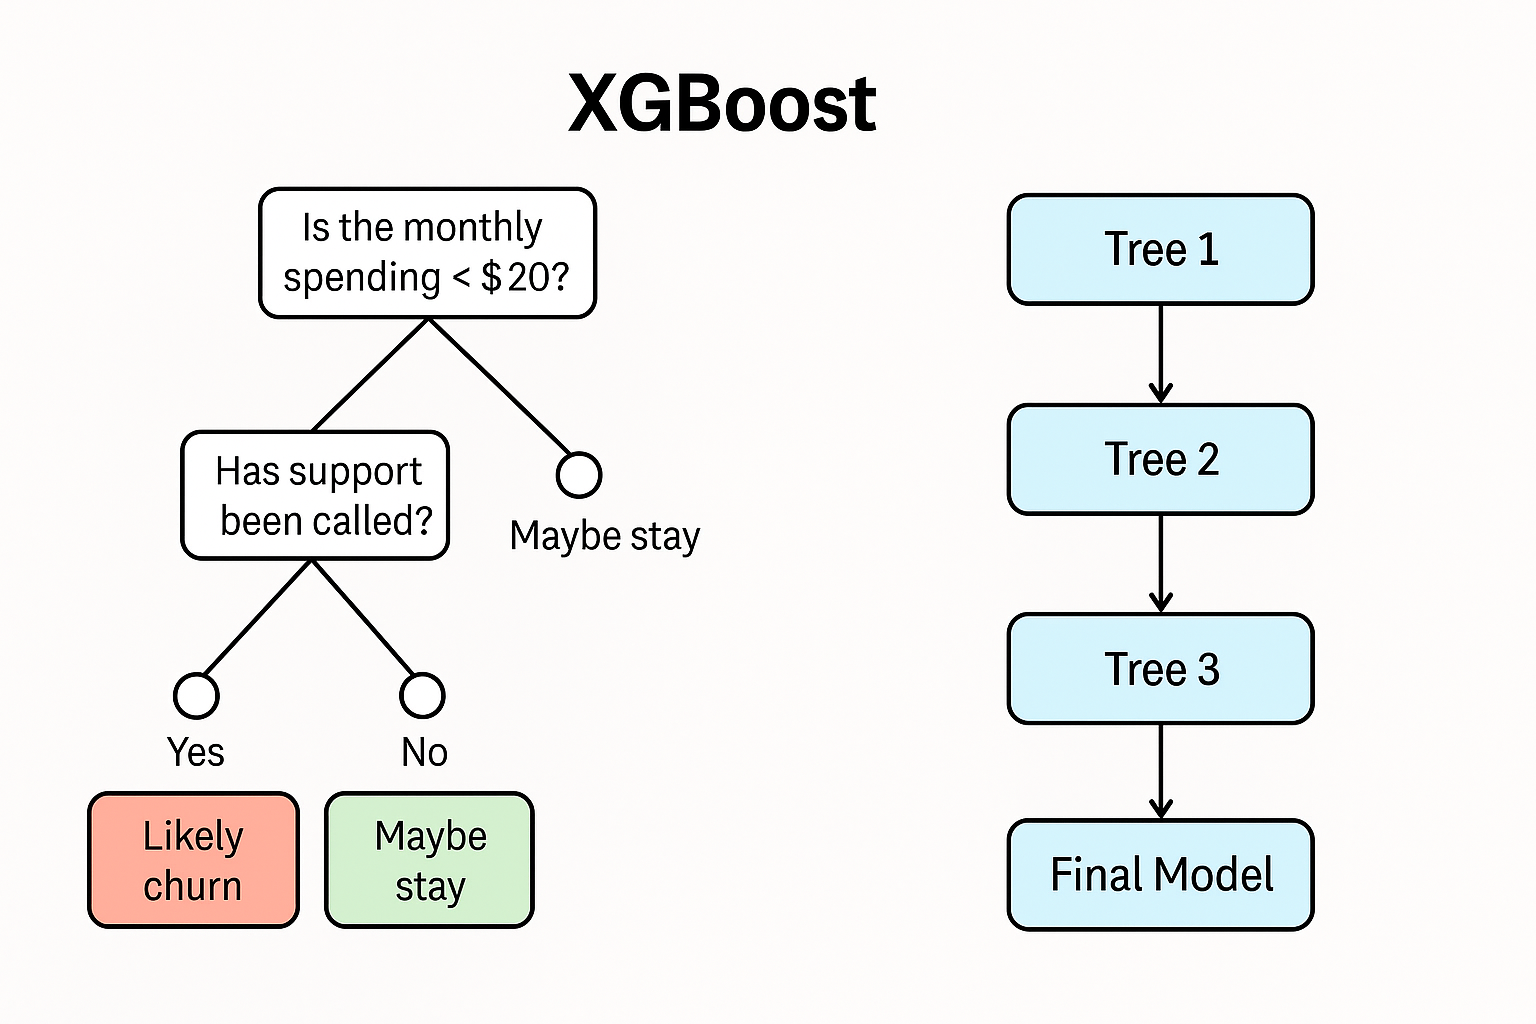


 `What “CART” Means in XGBoost`

CART stands for Classification and Regression Tree.
It’s the type of decision tree that XGBoost uses as its building block.

So when we say XGBoost builds many trees, each of those trees is a CART.

  `CART in Simple Terms`

A CART is like a flowchart that asks yes/no questions to split data into smaller and smaller groups — until it can make a prediction like the ones we've see above

`How CART Works Inside XGBoost`

XGBoost doesn’t just make one CART.

It builds many small CARTs sequentially — each one:

Learns from the mistakes of the previous trees.

Adds a small correction to the prediction.

Together, these trees form a powerful ensemble model.

So, you can think of XGBoost as:

A team of CARTs working together — each improving the next.


 `A Simple Analogy`

Imagine you’re teaching students:

The first student (Tree 1) gives rough answers.

The next student (Tree 2) looks at where the first one went wrong and fixes it.

The next (Tree 3) corrects remaining errors.

Each “student” is a CART, and together they form XGBoost’s boosted model.

  `Key Features of CART`

| Feature              | Meaning                                                 |
| -------------------- | ------------------------------------------------------- |
| **Splits data**      | Uses conditions (e.g. “balance < 1000”) to divide data. |
| **Purity goal**      | Tries to make each branch contain mostly one class.     |
| **Leaf values**      | Stores predicted outcome (like 0.8 = likely churn).     |
| **Used in boosting** | Each new CART corrects previous prediction errors.      |


 `In Short`

✅ CART = Classification and Regression Tree

✅ It’s the basic unit (tree) used inside XGBoost.

✅ XGBoost builds many CARTs — each improving upon the previous ones.


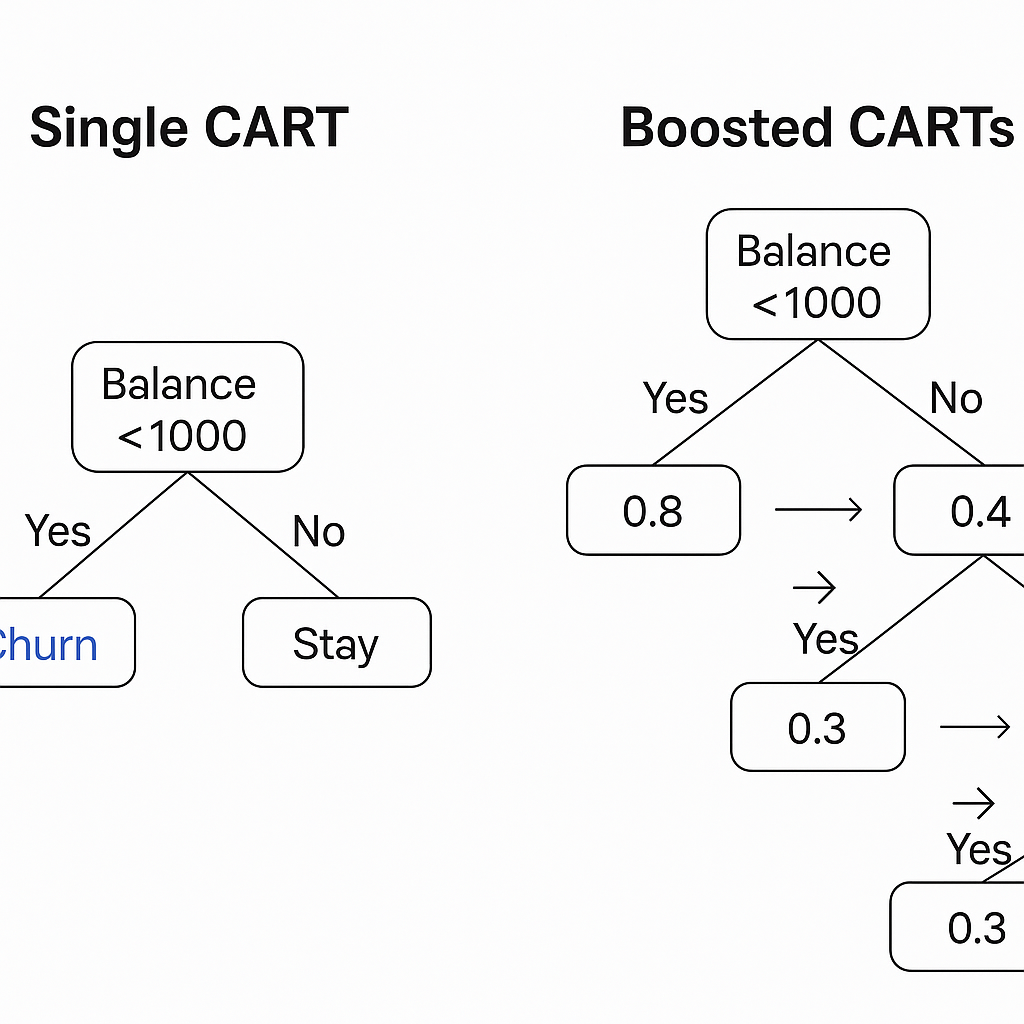

 `What is a DMatrix?`

A DMatrix is XGBoost’s special data structure — basically, its own super-efficient way to store your features (X) and labels (y).

You can think of it as a “turbocharged version of a pandas DataFrame or NumPy array.”

`dtrain = xgb.DMatrix(data=X, label=y)`

It contains:

* The feature values

* The target labels (optional)

* Optional weights for each sample

* Internal data indexing to make training blazing fast

 `Why XGBoost Uses DMatrix (and Not Just DataFrames)`

Here’s what happens under the hood:

| Reason                           | Explanation                                                                                                                                                       |
| -------------------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Speed and Memory Efficiency**  | XGBoost was designed for *big data*. DMatrix uses **compressed column storage (CSC/CSR)** formats, which take far less memory and load faster than normal arrays. |
| **Sparse Data Handling**         | Many real-world datasets have missing values (NaNs) or zeros — DMatrix stores these efficiently and knows how to handle them automatically.                       |
| **Pre-computed Statistics**      | DMatrix pre-computes **column means, gradients, and Hessians** (used during tree building), so XGBoost doesn’t redo the same work every iteration.                |
| **Multi-Threading Optimization** | When you pass a DMatrix, XGBoost can **parallelize computations** across CPU cores easily.                                                                        |
| **Uniform Input Format**         | No matter if your original data comes from pandas, NumPy, or even a sparse matrix — DMatrix standardizes it into the same optimized format XGBoost expects.       |


`Analogy: Why DMatrix Matters`

Imagine you’re a chef 🍳

* Pandas/NumPy = ingredients still in their original packages (slow to access).

* DMatrix = all ingredients pre-chopped, measured, and laid out on the counter — ready for fast cooking.

That’s why when you train models with:

`xgb.train(params, dtrain, num_boost_round=10)`

…it runs much faster than if you used the scikit-learn API directly on a raw DataFrame.


`Bonus: When You Don’t Need to Use DMatrix Manually`

If you use the scikit-learn API (xgb.XGBClassifier, xgb.XGBRegressor), XGBoost automatically converts your data to DMatrix behind the scenes.

You only need to create it manually when you’re using:

* The learning API (xgb.train, xgb.cv, etc.)

* Large datasets that you want to optimize memory for

* Custom objectives or advanced tuning

 `In Short`

| Concept            | Summary                                                    |
| ------------------ | ---------------------------------------------------------- |
| **What it is**     | Optimized internal data structure for XGBoost              |
| **Why it matters** | Faster, smaller, smarter with sparse data                  |
| **When to use it** | When using the core XGBoost training API or large datasets |
| **Analogy**        | Like pre-processed, ready-to-cook ingredients            |


  `The Goal of a Split`

When XGBoost is growing a tree (CART), it keeps asking:

“Where should I split the data so that the predictions become more accurate?”

Each split divides the data into two groups, and XGBoost wants those groups to be as pure as possible — meaning each branch should mostly contain either “churners” or “non-churners”.

So the question becomes:

 Which feature and value (like “balance < 1000”) best separates the two groups?

 `The Secret Ingredient — Gain`

XGBoost doesn’t just guess; it calculates which split improves the model the most using a formula called `Gain.`

The Gain measures how much a split improves the model’s ability to make correct predictions.

In essence:

`Gain = Improvement after split - Cost of complexity`

It wants a high Gain → that means the split makes the data much clearer and improves accuracy.


 `How It Actually Decides`

Let’s imagine you have one feature: Balance.

| Customer | Balance | Churn |
| -------- | ------- | ----- |
| A        | 200     | Yes   |
| B        | 300     | Yes   |
| C        | 1000    | No    |
| D        | 1200    | No    |

XGBoost tries splitting at different points:

Balance < 250

Balance < 500

Balance < 1100

For each split, it measures:

How “pure” each side becomes (using gradient and hessian statistics — basically, the slope of the loss function).

How much that purity reduces the overall prediction error.

The split that gives the biggest reduction in error is chosen.


 `Simplified Formula (Intuitive)`

Each data point has:

`Gradient (g)` → how wrong the model currently is.

`Hessian (h)` → how confident the model is about that prediction.

For a possible split: `Gain = ½ * [ (GL² / HL) + (GR² / HR) - ((GL + GR)² / (HL + HR)) ] - γ`

Where:

`GL, HL` = sum of gradients and hessians for left side

`GR, HR` = sum of gradients and hessians for right side

`γ (gamma)` = penalty to avoid overfitting

 Don’t worry about the math — the idea is that XGBoost measures how much better a split reduces the total error.


  `Example Intuition`

Let’s say:

If we split at balance < 1000, we separate churners from non-churners almost perfectly.

That means our Gain is large → XGBoost says “Yes! That’s a great split!”

If the split barely changes anything (still a mix of churners/non-churners), the Gain will be small or negative → XGBoost skips it.

`The Process Repeats`

It keeps splitting further down:

Find the best split.

Grow branches.

Stop when:

No further Gain is achieved, or

Tree becomes too deep.

This is how each CART is built — mathematically choosing the most useful questions.

 `Boosting Makes It Smarter`

After the first tree is built, XGBoost checks where it made errors and:

Updates gradients (what it got wrong)

Builds a new tree focusing on those hard-to-predict cases.

So the next tree learns from the mistakes of the previous one.

 `Summary in Plain English`


| Step | What Happens                    | Why                      |
| ---- | ------------------------------- | ------------------------ |
| 1️⃣  | Model makes initial predictions | Usually 0.5 for everyone |
| 2️⃣  | Calculates gradients (errors)   | Finds where it’s wrong   |
| 3️⃣  | Chooses best split using Gain   | Splits data smartly      |
| 4️⃣  | Builds a new tree to fix errors | Boosts performance       |
| 5️⃣  | Repeats many times              | Accuracy keeps improving |


#### What is Similarity Score?

Imagine you’re building a decision tree

Let’s say you have a group of students and you want to split them based on a rule like:

“Does the student study more than 2 hours per day?”

You want each group to be as pure as possible —
meaning each side has mostly students who pass or fail, not a mix.

`XGBoost builds trees — but it does it mathematically smartly`

At each possible split, XGBoost asks:

“If I split here, will my two groups become more pure?
How much better will this split make my predictions?”

That “how much better” feeling is what XGBoost measures with gain or similarity score.


`What is Similarity Score (in simple terms)?`

Think of it like a measure of how consistent or similar the data points in a leaf are.

If a leaf has mostly similar outcomes (e.g., everyone in that group “passes”),
→ the similarity score is high.

If a leaf is mixed (half pass, half fail),
→ the similarity score is low.

So, the higher the similarity score, the better the split —
because it means that leaf is more “pure”.

`In slightly more technical but still simple words`

XGBoost keeps track of two things for every data point:

Gradient (g) → how wrong the model currently is

Hessian (h) → how confident the model is about that prediction

The similarity score for a leaf is computed as:

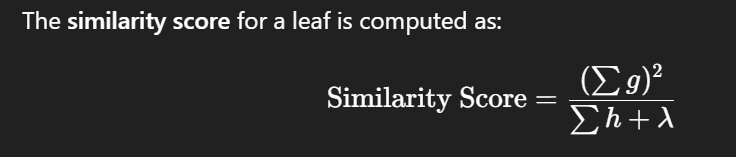

Where:

∑g = total gradient for that leaf

∑h = total hessian (second derivative, like confidence)

λ = regularization term to avoid overfitting (makes it smaller if leaf is too specific)

`Intuitive analogy`

Imagine the similarity score like a “reward” for grouping similar students together:

If all students in the group have similar grades, your group gets a high reward (good split).

If the group has mixed grades, you get a low reward (bad split).

XGBoost uses this reward to decide:

“Should I split here or somewhere else?”


`Summary`
| Term                      | Meaning (in child-friendly words)                                 |
| ------------------------- | ----------------------------------------------------------------- |
| **Leaf**                  | A group of data points that end up in the same branch of the tree |
| **Similarity score**      | How similar the points in that leaf are (how “pure” it is)        |
| **High similarity score** | The leaf mostly contains one type of output (good split)          |
| **Low similarity score**  | The leaf has mixed outcomes (bad split)                           |
| **Use in XGBoost**        | Used to decide the best place to split data when growing trees    |


`Simple story version:`

Think of XGBoost as a teacher sorting students by study habits.
It keeps splitting groups so that each leaf has students who behave similarly (either all pass or all fail).
The similarity score tells the teacher how “alike” each group is —
higher means the teacher grouped them perfectly!


### Summary of the paper, XGBoost: A Scalable Tree Boosting System
`What is XGBoost really?`

Imagine you have many tiny decision trees — little helpers that make guesses.

Each tree says things like:

“Hmm… if income < 30 K and age < 25 → maybe default = Yes.”
“If income > 60 K → default = No.”

Now, instead of using just one tree (which can be wrong),
XGBoost builds many trees, one after another,
and each new tree learns from the mistakes of the trees before it.

That’s the key idea of boosting —
each new tree gives the model a little “boost” in accuracy.

`How does XGBoost learn? (the “gradient” part)`

Think of it like this:

You start with a simple guess — like predicting everyone’s average value.
(e.g., “Let’s say everyone has a 0.3 chance of defaulting.”)

Then you check the mistakes — who you got wrong and by how much.
This difference is called the residual or gradient.

You build a small tree to fix those mistakes.
That tree says, “Hey, you predicted 0.3, but for these people, it should be 0.7!”

You keep adding more trees, each time reducing the remaining errors a bit more.

When the errors become tiny — you stop.
That’s Gradient Boosting — and XGBoost is a super-efficient version of it.

`The magic formula (in plain words)`

When the paper says this scary thing:


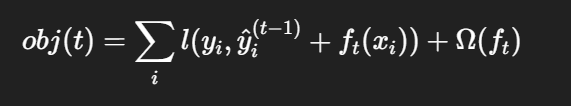


`Let’s decode it in human-speak:''

`y_i` = real answer (like “did the person default?” = 0 or 1)

`ŷ_i` = model’s current guess

`f_t(x_i)` = new tree’s prediction (the next little “fixer” tree)

`Ω(f_t)` = penalty for making trees too complicated (regularization)

So the model says:

“I want to build a new tree that fixes my mistakes
but doesn’t become too complicated.”

That’s why XGBoost is both smart and disciplined

`What is the “Gain” and “Similarity Score”?`

Remember when we talked about the similarity score earlier?

When a tree tries to decide where to split,
it checks: “If I split here, will I make my predictions more accurate?”

That improvement is called Gain,
and it’s based on the similarity score (how pure each side is).

Formally (don’t worry, we’ll simplify):


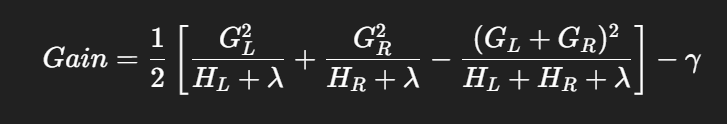


In plain language:

`G` = sum of gradients (how wrong we are)

`H` = sum of hessians (how confident we are)

`λ` = regularization (avoid overfitting)

`γ` = cost of making a split (don’t split unless it helps a lot)

So the split is only made if the gain > γ.

`The “Regularization” — the model’s self-control`

Regularization is like telling your model:

“Don’t just memorize everything — stay simple!”

XGBoost adds a small penalty when:

* You make too many leaves (too many rules)

* The leaf values are huge (too confident)

This keeps the model from “overfitting” or memorizing training data.

`Why XGBoost is faster and smarter than older models`

The paper introduced several engineering tricks that make it blazing fast:

| Trick                      | Meaning (kid-friendly)                                                                                          |
| -------------------------- | --------------------------------------------------------------------------------------------------------------- |
| **Histogram optimization** | Instead of checking every possible split value, it groups values into “bins” — like sorting numbers into boxes. |
| **Parallel learning**      | Builds parts of trees simultaneously using multiple CPU cores.                                                  |
| **Cache awareness**        | Uses your computer’s memory efficiently, so it doesn’t waste time fetching data.                                |
| **Sparsity-aware**         | Automatically handles missing values (treats them like “don’t know yet” cases).                                 |


`So, it’s not just smart math — it’s smart engineering` ⚙️💨



#### Why it became famous

Because it combined:

* Math (gradient boosting)

* Regularization (self-control)

* Speed (optimized C++ code)

* Flexibility (classification, regression, ranking)

It became the most popular model in Kaggle competitions
and is still one of the strongest algorithms for structured/tabular data.

`In short (story form)`

`XGBoost` is like a classroom of very disciplined students (trees).
Each one takes turns fixing the mistakes of the previous one.
The teacher (the algorithm) keeps them from over-studying (regularization).
And the principal (engineer) makes sure the classroom runs super fast (optimizations).
By the end, the class together becomes the smartest predictor in school

`What is an Ensemble?`

Imagine you’re trying to guess how many sweets are in a big jar 🍬.

You ask one friend → they might guess 50.

You ask another → they guess 70.

You ask a third → they say 60.

If you take the average (say, 60), it’s often closer to the truth than any single guess.
That’s the power of a group decision.

That group of friends is your ensemble

`Ensemble models in machine learning`

In machine learning, an ensemble model is when we combine many smaller models (like decision trees or neural nets) to make one stronger, more accurate model.

Each small model is like one “friend” giving an opinion.
The ensemble listens to all of them — and makes a final decision that’s usually smarter and more stable than any single one.


`Two main types of ensemble models`

| Type         | Simple Example                    | How it works                                                                                          | Common algorithms           |
| ------------ | --------------------------------- | ----------------------------------------------------------------------------------------------------- | --------------------------- |
| **Bagging**  |  Random Forest                  | Many trees trained independently on random parts of data, then vote together                          | Random Forest               |
| **Boosting** |  XGBoost, LightGBM, CatBoost    | Trees are built **one after another**, each new one fixes the mistakes of the previous ones           | XGBoost, CatBoost, LightGBM |
| **Stacking** |  Team of different model types | Combines predictions from *different kinds* of models (e.g., tree + logistic regression + neural net) | Stacked Ensembles           |





`Bagging — “Learning in parallel”`

Bagging means Bootstrap Aggregating (don’t worry about the big word 😅).

Imagine you have 100 students in a class.
You let each tree see a random subset of the students.
Every tree learns slightly different things.
At the end, they all vote on the answer.

That’s Random Forest — a bagging ensemble.
They’re all independent learners who vote together



`Boosting — “Learning in sequence”`

Boosting means we train one tree at a time, like a relay race 🏃‍♂️🏃‍♀️🏃‍♂️

* Tree 1 learns and makes some mistakes.

* Tree 2 learns from those mistakes.

* Tree 3 fixes what Tree 2 missed.

Each new tree boosts the performance of the whole team.
This is how XGBoost, LightGBM, and CatBoost work.

By the end, they’ve all learned from each other — and become super smart



`Stacking — “A team of experts”`

Sometimes, you combine different types of models —
like one decision tree, one logistic regression, and one neural network.

Then you train a meta-model (like a teacher) to learn how to combine their answers best.
That’s stacking — like having a team of different specialists work together


`Why ensembles are powerful`

✅ They reduce errors — if one model is wrong, others can correct it.
✅ They reduce overfitting — averages smooth out noisy predictions.
✅ They improve stability — less sensitive to random data quirks.

It’s like having a group of experts instead of one —
the group decision is more trustworthy.

`In short (story form)`

An ensemble model is like a classroom of students (models).
Each one makes a guess, and then the teacher (the algorithm)
takes all their answers and finds the best combined prediction.
Together, they become much smarter than any single student!

 `What is Isolation Forest?`

Isolation Forest is an unsupervised anomaly detection algorithm — meaning it doesn’t need labeled data (no “churn” vs “stay”).
Its main goal is to detect outliers or unusual patterns in your dataset.

Think of it like a security guard  that looks through data to find “something weird” — for example:

A customer making an unusually large transaction 

A device sending data at odd hours 

A merchant reversing payments too frequently 

 `How It Works`

It builds many random decision trees, but instead of predicting something (like churn), it tries to isolate each data point.

Normal points take many splits to isolate (harder to separate — they look like others).

Anomalies take fewer splits to isolate (they’re unique or different).

 The fewer splits needed → the more likely it’s an outlier.

Tiny Example

Imagine these numbers:

`Normal: 50, 51, 52, 53, 54`

`Outlier: 500`

To isolate 500, you just split once (“>100?”).

To isolate 52, you’d need many finer splits (“<54?”, “>50?” etc.).

Hence, 500 is an anomaly — easily isolated!

 `Output`

The model gives each point an anomaly score:

`Close to 1.0 → anomaly`

`Close to 0.0 → normal`


  `What is XGBoost?`

`XGBoost (Extreme Gradient Boosting)` is a supervised learning algorithm — meaning it needs labeled data (like churn = 1, not churn = 0).
It’s used for:

Classification (e.g., churn prediction)

Regression (e.g., sales forecasting)

It builds many small decision trees sequentially, each one improving upon the last, to make highly accurate predictions.

 `The Key Differences`

| Feature              | **Isolation Forest**                               | **XGBoost**                                         |
| -------------------- | -------------------------------------------------- | --------------------------------------------------- |
| **Type of Learning** | Unsupervised                                       | Supervised                                          |
| **Goal**             | Detect anomalies / outliers                        | Predict a target (e.g., churn)                      |
| **Data Required**    | Only features (no labels)                          | Features **and** target labels                      |
| **How It Learns**    | Randomly splits data to isolate unusual points     | Builds trees to minimize prediction error           |
| **Main Output**      | Anomaly score (0–1)                                | Predicted value or class label                      |
| **Use Cases**        | Fraud detection, network intrusion, faulty sensors | Churn prediction, credit scoring, sales forecasting |
| **Interpretability** | Focuses on “how easy to isolate”                   | Focuses on “what patterns best predict outcome”     |
| **Speed**            | Fast for large datasets                            | Fast and scalable but depends on boosting rounds    |


 `Analogy`

Think of your data like a forest of customers 

`Isolation Forest:` walks through the forest looking for the odd-looking trees 

“Hmm, this one’s too tall — something’s off!”

`XGBoost:` walks through the forest trying to predict which trees will bear fruit 

“Based on height, leaves, and soil, this one will probably grow apples.”

Both use trees — but for very different goals.

 `When to Use Each`

| When to Use                                                | Best Choice        |
| ---------------------------------------------------------- | ------------------ |
| You **don’t have labels** and want to find unusual records | ✅ Isolation Forest |
| You **have labels** and want to predict an outcome         | ✅ XGBoost          |
| You suspect **fraudulent, abnormal, or rare events**       | Isolation Forest   |
| You want to **forecast or classify** things                | XGBoost            |


 `In Summary`

| Model                | Purpose           | Key Idea                                             |
| -------------------- | ----------------- | ---------------------------------------------------- |
| **Isolation Forest** | Detects anomalies | “Is this record different from the rest?”            |
| **XGBoost**          | Predicts outcomes | “Given past examples, what’s likely to happen next?” |


⚡ 4️⃣ *When to Use Which*

✅ `Use XGBoost when:`

Your dataset is medium-sized (up to a few million rows).

You want a stable, well-tested, widely-used model.

You prefer interpretability and less tuning hassle.

You want consistent results without worrying about overfitting.

⚡ `Use LightGBM when:`

You’re working with very large datasets (millions+ rows).

You need faster training (LightGBM can be 5–10× faster).

You want to leverage categorical features directly.

You’re comfortable doing fine-tuning to prevent overfitting.


`Quick Analogy`

| Situation                               | Algorithm                                                           |
| --------------------------------------- | ------------------------------------------------------------------- |
| Small–medium dataset, reliability first | 🚗 **XGBoost** (like a Toyota — stable, solid, predictable)         |
| Very large dataset, speed matters       | 🚀 **LightGBM** (like a Ferrari — fast, but needs skilled handling) |
